1. Nền tảng
    Hồi quy là gì & các khái niệm cốt lõi (Hàm mất mát, Gradient Descent, Overfitting).
2. Bước đầu tiên
    Hồi quy tuyến tính Đơn biến.

3. Mở rộng sức mạnh
    Hồi quy tuyến tính Đa biến.

4. Thử thách mới
    Hồi quy Logistic cho bài toán phân loại.

5. Tổng kết
    So sánh và lựa chọn mô hình.

Hồi quy là gì? Dự đoán một giá trị liên tục

    · Định nghĩa: Hồi quy (Regression) là phương pháp học có giám sát nhằm dự đoán một giá trị đầu ra liên tục (số thực) từ các biến đầu vào.

    · Công thức: Cho tập dữ liệu {(x1,y1), ... , (Xm.yn)}, mục tiêu là tìm hàm f sao cho f(x) ~ y.

    · Ví dụ: Dự đoán giá nhà dựa trên diện tích. Nhà 80m2 > Giá 2.4 tỷ VNĐ.

Làm sao để đo lường "sai số" của mô hình?
    Khái niệm: Hàm Mất Mát (Loss Function) đo lường sự chênh lệch giữa giá trị dự đoán (ŷ) và giá trị thực tế (y). Mục tiêu của chúng ta là tối thiểu hóa hàm này.
    
    Hàm phổ biến nhất: Mean Squared Error (MSE):

    MSE = 1/n x ∑(n; i=1)(yi​−ŷi)^2

    Giải thích:
        n: số lượng mẫu dữ liệu
        yi: giá trị dự đoán của mô hình cho mẫu thứ i
        ŷi: giá trị dự đoán của mô hình cho mẫu thứ i


Làm sao để tìm ra mô hình "tốt nhất"
    Thuật toán: Gradient Descent (dùng đạo hàm)
    Ý tưởng: Tưởng tượng hàm mất mát là
    một thung lũng. Chúng ta bắt đầu từ
    một điểm ngẫu nhiên trên sườn dốc và
    đi từng bước nhỏ theo hướng dốc nhất
    xuống dưới để tìm điểm thấp nhất (cực
    tiểu).

    Công thức cập nhật: θ := θ - α x ∂L/∂θ

Thử thách cân bằng: Underfitting và Overfitting
    Underfitting: Mô hình quá đơn giản, hàm f(x) (giá trị dự đoán của mô hình) chỉ là một đường thẳng, đi qua ít điểm hơn => MSE sẽ lớn.

    Good Fit: Mô hình phù hợp, hàm f(x) (giá trị dự đoán của mô hình) có thể là một đường cong -> sẽ đi qua nhiều điểm hơn => MSE sẽ nhỏ hơn.

    Overfitting: Mô hình quá phức tạp, hàm f(x) (giá trị dự đoán của mô hình) hầu như đi qua mọi điểm của dữ liệu thực tế.
    
Hồi quy Đơn biến: Một đầu vào, một đầu ra
    ŷ = W0 + W1X (The blue print formula)
        W0: Hệ số chặn (intercept) - Giá trị của y khi x=0.
        W1: Hệ số góc (slope) - Mức độ thay đổi của y khi x thay đổi 1 đơn vị.


Đánh giá mô hình Hồi quy tuyến tính

    R2 (R-squared)
    Ý nghĩa: Tỷ lệ phần trăm
    phương sai của biến đầu ra
    (y) được giải thích bởi mô
    hình.
    Giá trị: Từ 0 đến 1. Càng gần
    1, mô hình càng giải thích
    được nhiều.

        R^ 2 = 1- [∑(yi - ŷi)^2 / (yi - y(mean)i)^2]

    MAE (Mean Absolute Error)
    Ý nghĩa: Sai số trung bình
    tuyệt đối. Dễ diễn giải vì
    cùng đơn vị với biến đầu ra.
        MAE = 1/n x |∑(yi - ŷi)|

    MSE (Mean Squared Error)
    Ý nghĩa: Sai số trung bình
    bình phương. Phạt nặng các
    lỗi dự đoán lớn (outliers) do
    bình phương sai số.

        MSE = 1/n x ∑(yi​−ŷi)^2


Hồi quy Đa biến: Thêm nhiều yếu tố để dự đoán tốt hơn
    The Question: Sẽ ra sao nếu giá nhà không chỉ phụ thuộc vào diện tích mà còn cả vị trí, số phòng ngủ, và năm xây dựng?
    
    The Blueprint (Formula): y = Wo + W1X1 + W2X2 + ... + WpXp

    The Core Idea: Chúng ta không còn tìm một đường thầng (line) trong không gian 2D, mà là một siêu phầng (hyperplane) trong không gian nhiều chiều.   



In [2]:
# py -m pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import  LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

[ 1  1  1  1  2  2  2  2  2  3  3  3  4  4  4  4  5  5  5  5  5  5  5  5
  5  6  6  6  7  7  7  7  8  8  8  8  8  9  9  9 10 10 10 11 11 11 12 12
 12 12 13 13 14 14 14 14 15 15 15 15 15 16 16 16 16 17 17 17 17 18 18 18
 18 18 19 19 19 19 19 19]
[ 1  3  4  5  6  6  7  7  7 10 10 10 11 13 15 15 17 17 18 19]


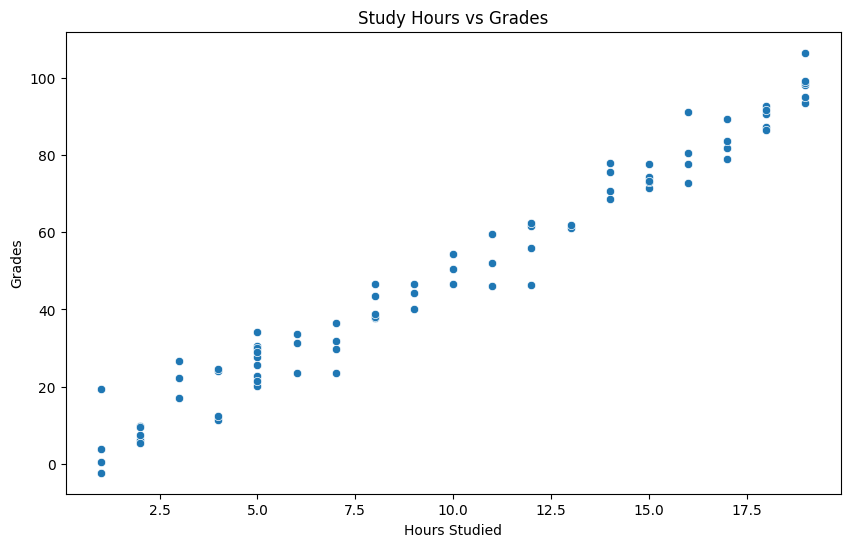

In [3]:
hours = np.random.choice(range(1, 20), 100)

hours_train = hours[:80]
hours_test = hours[80:]
hours_train.sort()
hours_test.sort()
print(hours_train)
print(hours_test)

grades_train = 5 * hours_train + np.random.normal(0, 5, 80)
grades_test = 5 * hours_test + np.random.normal(0, 5, 20)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=hours_train, y=grades_train)
plt.title('Study Hours vs Grades')
plt.xlabel('Hours Studied')
plt.ylabel('Grades')
plt.show()

5.024415838076457
-0.28830993829935636
[ 4.7361059  14.78493758 19.80935341 24.83376925 29.85818509 29.85818509
 34.88260093 34.88260093 34.88260093 49.95584844 49.95584844 49.95584844
 54.98026428 65.02909596 75.07792763 75.07792763 85.12675931 85.12675931
 90.15117515 95.17559099]
Coefficient (a): 5.024415838076457
Intercept(b): -0.28830993829935636


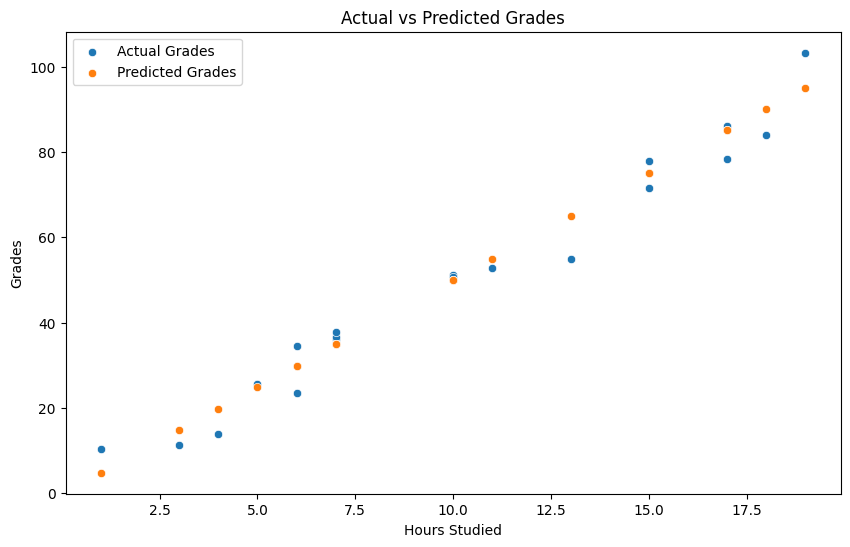

R^2: 0.9688206357784652
Mean Squared Error: 21.607195387580937


In [4]:
grade_predictor = LinearRegression()
grade_predictor.fit(hours_train.reshape(-1, 1), grades_train)
print(grade_predictor.coef_[0])
print(grade_predictor.intercept_)
grade_predictions = grade_predictor.predict(hours_test.reshape(-1, 1))
print(grade_predictions)

# y = ax + b
print("Coefficient (a):", grade_predictor.coef_[0])
print("Intercept(b):", grade_predictor.intercept_)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=hours_test, y=grades_test, label='Actual Grades')
sns.scatterplot(x=hours_test, y=grade_predictions, label='Predicted Grades')
plt.title('Actual vs Predicted Grades')
plt.xlabel('Hours Studied')
plt.ylabel('Grades')
plt.legend()
plt.show()

r2 = grade_predictor.score(hours_test.reshape(-1, 1), grades_test)
mse = np.mean((grades_test - grade_predictions) ** 2)
print(f'R^2: {r2}')
print(f'Mean Squared Error: {mse}')

In [5]:
df = pd.read_csv('data_simple_reg.csv')
df.info()
df.dropna(inplace=True)
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4572 non-null   int64  
 1   Quang_Cao  4562 non-null   float64
 2   Tiep_Thi   4568 non-null   float64
 3   Online     4566 non-null   float64
 4   Doanh_So   4566 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 178.7 KB
<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4546 non-null   int64  
 1   Quang_Cao  4546 non-null   float64
 2   Tiep_Thi   4546 non-null   float64
 3   Online     4546 non-null   float64
 4   Doanh_So   4546 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 213.1 KB


,TT,Quang_Cao,Tiep_Thi,Online,Doanh_So
0,0,12.0,5.993562,3.730133,79.732757
1,1,13.0,6.741511,3.006753,71.677897
2,2,41.0,15.405956,2.987338,175.177829
3,3,78.0,28.294987,6.934639,323.246340
4,4,11.0,6.663944,1.633811,81.594181


4091 (455,) (4091,) (455,)
Coefficient (a): 3.5219106687772066
Intercept(b): 42.8584401474391


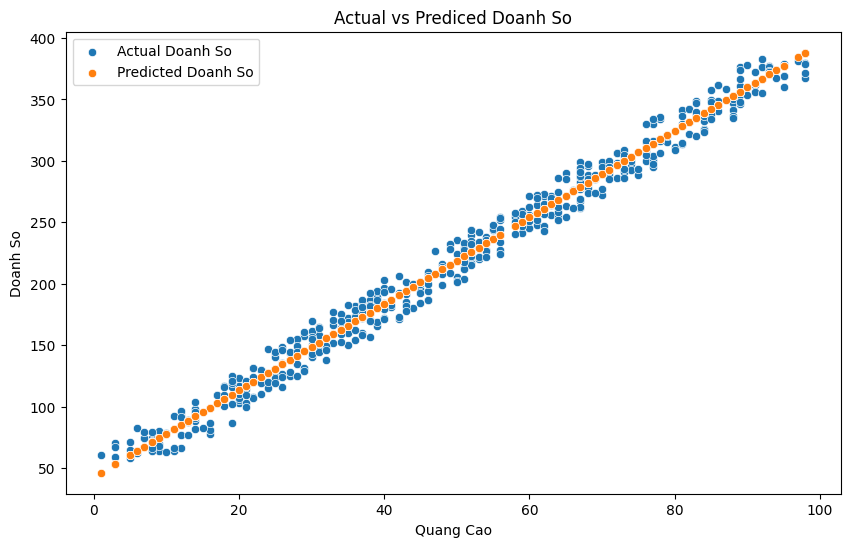

R-square of qcModel: 0.9863987385668086
MSE of qcModel: 107.55864520190353


In [6]:
x_qc = df['Quang_Cao']
y_ds = df['Doanh_So']

x_qc_train = x_qc[:90]
x_qc_test = x_qc[90:]
y_ds_train = y_ds[:90].values
y_ds_test = y_ds[90:].values

# Or use sklearn.model_selection train_test_split
x_qc_train, x_qc_test, y_ds_train, y_ds_test = train_test_split(x_qc, y_ds, test_size=0.1, random_state=42)

print(len(x_qc_train), x_qc_test.shape, y_ds_train.shape, y_ds_test.shape)

qcModel = LinearRegression()
qcModel.fit(x_qc_train.values.reshape(-1, 1), y_ds_train.values)

# y = ax + b
print("Coefficient (a):", qcModel.coef_[0])
print("Intercept(b):", qcModel.intercept_)

# predict y test
dsPrediction = qcModel.predict(x_qc_test.values.reshape(-1, 1))

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_qc_test, y=y_ds_test, label='Actual Doanh So')
sns.scatterplot(x=x_qc_test, y=dsPrediction, label="Predicted Doanh So")
plt.title('Actual vs Prediced Doanh So')
plt.xlabel('Quang Cao')
plt.ylabel('Doanh So')
plt.legend()
plt.show()

print('R-square of qcModel:', r2_score(y_ds_test, dsPrediction))
print('MSE of qcModel:', mean_squared_error(y_ds_test, dsPrediction))

In [7]:
df = pd.read_csv('data_multiple_reg.csv')
df

x = df[['PR', 'Online']]
y = df['Doanh_So']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
qcMultipleModel = LinearRegression()

qcMultipleModel.fit(x_train, y_train)

print("Coeficients:", qcMultipleModel.coef_)
print("Intercept:", qcMultipleModel.intercept_)

dsMulPrediction = qcMultipleModel.predict(x_test)

print('R-Square: ', r2_score(y_test, dsMulPrediction))
print('MSE: ', mean_squared_error(y_test, dsMulPrediction))

df


Coeficients: [7.79729743 1.53478793]
Intercept: 72.48797770580825
R-Square:  0.6218100908639569
MSE:  2961.9895308759837


,TT,Quang_Cao,PR,Online,KOL,Doanh_So
0,0,Low,1.034766,4.297423,Micro,80.261284
1,1,Low,5.340160,0.744989,Mega,92.574904
2,2,High,21.918056,0.004401,Micro,297.250108
3,3,Medium-High,20.288928,0.688838,Mega,220.102176
4,4,High,30.048338,7.365014,Nano,298.960377
...,...,...,...,...,...,...
567,567,Medium-Low,16.461286,2.883458,Micro,216.521266
568,568,High,28.512999,6.675807,Mega,322.626731
569,569,Medium-Low,9.573457,4.508572,Nano,170.416851
570,570,Medium-High,23.390934,6.925610,Macro,234.326830


In [8]:
qc_encode = pd.get_dummies(df['Quang_Cao'])
qc_encode

x = pd.concat([qc_encode, df[['PR', 'Online']]], axis=1)
x
y = df['Doanh_So']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
qcMultipleModel = LinearRegression()

qcMultipleModel.fit(x_train, y_train)

# y = ax1 + bx2 + cx3 + dx4 + ex5 + fx6 + g
print("Coeficients (a, b,c, d, e, f):", qcMultipleModel.coef_)
print("Intercept (g):", qcMultipleModel.intercept_)

dsMulPrediction = qcMultipleModel.predict(x_test)

print('R-Square: ', r2_score(y_test, dsMulPrediction))
print('MSE: ', mean_squared_error(y_test, dsMulPrediction))

Coeficients (a, b,c, d, e, f): [ 80.67102349 -82.57129165  24.84463974 -22.94437158   2.20205675
   0.67667531]
Intercept (g): 179.53127575835305
R-Square:  0.9201077693745625
MSE:  625.7172520849864


Hồi quy Logistic: Khi câu trả lời là Có/Không

    Chúng ta không còn dự đoán một con số (như giá nhà 3.1 tỷ). Thay
    vào đó, ta dự đoán một xác suất (từ 0 đến 1) của một sự kiện.

    · Ví dụ
        Khách hàng này sẽ mua hàng (1) hay không (0)?
        Email này là spam (1) hay không (0)?
        Bệnh nhân có mắc bệnh (1) hay không (0)?

    Đây là bài toán phân loại nhị phân, nhưng chúng ta giải quyết nó
    bằng một công cụ mang tên 'hồi quy'.





Chìa khóa Sigmoid: Biến đổi đầu ra thành xác suất
    The Tool: Để đảm bảo đầu ra luôn
    nằm trong khoảng (0, 1), chúng ta
    sử dụng hàm Sigmoid.

    Formula: σ(z) = 1/(1+e^-z)

    Trong đó z = Wo + W1X1 + ...

Ranh giới quyết định: Đường phân chia thế giới
    Key Idea: Mô hình Logistic không vẽ một đường đi qua các điểm dữ liệu. Thay vào đó, nó
    học một ranh giới quyết định (Decision Boundary) để phân chia các nhóm.
    Rule: Ranh giới này là nơi mô hình "phân vân" nhất, tức là P(y=1|x) = 0.5.

Bộ công cụ mới cho bài toán phân loại

    Hàm Mất Mát Mới
        Không dùng: MSE (vì hàm không lồi với Sigmoid, khó tối ưu).
        Sử dụng: Binary Cross-Entropy
        Ý tưởng: Phạt nặng các dự đoán sai một cách "tự tin" (ví dụ: dự đoán xác suất 0.9 cho một sự kiện thực tế không xảy ra).

        L = -1/n x ∑[yilog(ŷi)+(1-yi)log(1-ŷi)]

    Chỉ số đánh giá mới
        True Possitive (TP): dự báo CÓ và đúng là CÓ
        True Negative (TN): dự báo CÓ nhưng lại là KHÔNG CÓ
        False Possitive (FP): dự báo là KHÔNG và đúng là KHÔNG
        False Negative (FN): dự báo là KHÔNG nhưng lại là CÓ

        Không dùng: R2, MAE.
        Sử dụng:
        Accuracy: Tỷ lệ dự đoán đúng trên tổng số.
        Precision: Trong số những lần dự đoán là 'Có', có bao nhiêu lần là đúng? = TP/TP + FP
        Recall: Trong số tất cả các trường hợp 'Có' thực tế, mô hình tìm thấy được bao nhiêu? = TP / TP + FN
        F1-Score: Trung bình điều hòa của Precision và Recall. = 2 x P x Re / (P + Re)







In [9]:
lgDf = pd.read_csv('data_logistic_reg.csv')

print(lgDf.info())
lgDf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129880 non-null  int64  
 1   Danh_Gia              129880 non-null  object 
 2   Chat_Luong_Tai_Xe     129880 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.0+ MB
None


,TT,Danh_Gia,Chat_Luong_Tai_Xe,Thoi_Gian_vs_Du_Kien
0,0,satisfied,6,-11.56250
1,1,satisfied,1,-12.34375
2,2,satisfied,1,-11.56250
3,3,satisfied,6,-11.56250
4,4,satisfied,3,-11.56250
...,...,...,...,...
129875,129875,satisfied,6,-11.56250
129876,129876,dissatisfied,1,-11.87500
129877,129877,dissatisfied,2,-10.31250
129878,129878,dissatisfied,2,-9.68750


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
lgDf['Danh_Gia'] = encoder.fit_transform(lgDf['Danh_Gia'])
print(lgDf.info())
lgDf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129880 non-null  int64  
 1   Danh_Gia              129880 non-null  int64  
 2   Chat_Luong_Tai_Xe     129880 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 4.0 MB
None


,TT,Danh_Gia,Chat_Luong_Tai_Xe,Thoi_Gian_vs_Du_Kien
0,0,1,6,-11.56250
1,1,1,1,-12.34375
2,2,1,1,-11.56250
3,3,1,6,-11.56250
4,4,1,3,-11.56250
...,...,...,...,...
129875,129875,1,6,-11.56250
129876,129876,0,1,-11.87500
129877,129877,0,2,-10.31250
129878,129878,0,2,-9.68750


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lgDf.dropna(inplace=True)
print(lgDf.info())

x = lgDf[['Chat_Luong_Tai_Xe', 'Thoi_Gian_vs_Du_Kien']]
y = lgDf['Danh_Gia']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

lgModel  = LogisticRegression()
lgModel.fit(x_train, y_train)

danhGiaPrediction = lgModel.predict(x_test)
#====
print('Accuracy score: ', accuracy_score(y_test, danhGiaPrediction))
print('Precision score: ', precision_score(y_test, danhGiaPrediction))
print('Recall score: ', recall_score(y_test, danhGiaPrediction))
print('F1 score: ', f1_score(y_test, danhGiaPrediction))

# Phi tuyến là gì (sẽ dùng mạng nơ ron)? Tuyến tính là gì? 

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129487 non-null  int64  
 1   Danh_Gia              129487 non-null  int64  
 2   Chat_Luong_Tai_Xe     129487 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 4.9 MB
None
Accuracy score:  0.80206965788864
Precision score:  0.8148984198645598
Recall score:  0.8219723922015084
F1 score:  0.818420120439249


Tổng kết: Bộ công cụ Hồi quy của bạn
    Hồi quy Đơn biến
        Loại đầu ra: Liên tục (Số thực)
        Công thức cốt lõi: ŷ = Wo + W1X
        Hình dung mô hình: Đường thắng (2D)
        Hàm Mất mát: Mean Squared Error (MSE)
        Chỉ số đánh giá: R2, MAE, MSE

    Hồi quy Đa biến
        Loại đầu ra: Liên tục (Số thực)
        Công thức cốt lõi: ŷ = w^T X
        Hình dung mô hình: Đường thắng (2D)
        Hàm Mất mát: Mean Squared Error (MSE)
        Chỉ số đánh giá: R2, Adjusted R2

    Hồi quy Logistic
        Loại đầu ra: Xác suất (0-1) > Phân loại
        Công thức cốt lõi: ŷ = σ(w^T X)
        Hình dung mô hình: Ranh giới quyết định
        Hàm Mất mát: Binary Cross-Entropy
        Chỉ số đánh giá: Accuracy, Precision, Recall, F1